# Package

# Import Artifact

In [4]:
import os
import json
import joblib
import pandas as pd
import mlflow
from mlflow.tracking import MlflowClient

mlflow.set_tracking_uri("http://127.0.0.1:5000")
client = MlflowClient()

EXPERIMENT_NAME = "Multivariate_Experimentation"
exp = client.get_experiment_by_name(EXPERIMENT_NAME)
assert exp is not None, f"Experiment introuvable: {EXPERIMENT_NAME}"
exp_id = exp.experiment_id

runs = mlflow.search_runs(
    experiment_ids=[exp_id],
    order_by=["start_time DESC"]
)
runs[["run_id","tags.mlflow.runName","start_time"]].head()

,run_id,tags.mlflow.runName,start_time
0,e8ccd443e8254112aaab5d5ff447090f,RIDGE_ALL,2026-02-27 14:59:49.575000+00:00
1,043227d528cd4f61886cfa9269215beb,RIDGE_2020-end,2026-02-27 14:59:49.182000+00:00
2,3b4990c72caa430987bf7463c70243e1,RIDGE_2009-2019,2026-02-27 14:59:48.787000+00:00
3,141923d951eb48c9a5959e9352a87955,RIDGE_2000-2008,2026-02-27 14:59:48.389000+00:00
4,5cf9119c780c4022bba66c5b8ef80834,RIDGE_1990-1999,2026-02-27 14:59:48.003000+00:00


In [5]:
def download_all_artifacts(run_id: str, dst_dir: str = "mlruns_download"):
    os.makedirs(dst_dir, exist_ok=True)
    local_dir = mlflow.artifacts.download_artifacts(run_id=run_id, dst_path=dst_dir)
    return local_dir

# Exemple: prendre le run le plus récent
latest_run_id = runs.iloc[0]["run_id"]
local_path = download_all_artifacts(latest_run_id, dst_dir="mlruns_download/latest")
local_path

'd:\\Portofolio Data science\\Time Series\\Explainable_AI_Forecast_and_explain_the_Unemployment_of_USA\\3_notebook\\ML Experiment\\mlruns_download\\latest\\'

In [6]:
import glob

def load_run_bundle(local_path: str):
    out = {}

    # --- leaderboard ---
    lb = glob.glob(os.path.join(local_path, "leaderboard", "*.csv"))
    out["leaderboard"] = pd.read_csv(lb[0]) if lb else None

    # --- partition summary ---
    ps = glob.glob(os.path.join(local_path, "partition_summary.csv"))
    out["partition_summary"] = pd.read_csv(ps[0]) if ps else None

    # --- data parquet (bkt par partition + full) ---
    data_files = glob.glob(os.path.join(local_path, "data", "*.parquet"))
    out["data_parquets"] = {os.path.basename(p): pd.read_parquet(p) for p in data_files}

    # --- modèles (joblib) ---
    model_files = glob.glob(os.path.join(local_path, "model", "*.joblib"))
    out["models"] = {os.path.basename(p): joblib.load(p) for p in model_files}

    return out

bundle = load_run_bundle(local_path)

bundle["leaderboard"].head() if bundle["leaderboard"] is not None else "no leaderboard"

,unique_id,model_label,model_name,partition,mae,coverage,width,n
0,UNRATE,LGBM,LGBM,1990-1999,0.434865,0.791667,1.561072,120
1,UNRATE,LGBM,LGBM,2000-2008,0.517640,0.629630,1.286702,108
2,UNRATE,LGBM,LGBM,2009-2019,0.729249,0.803030,2.404650,132
3,UNRATE,LGBM,LGBM,2020-end,1.790125,0.764706,6.739885,68
4,UNRATE,LGBM,LGBM,ALL,0.761865,0.750000,2.574809,428


In [9]:
def download_and_load_experiment(exp_id: str, dst_root="mlruns_download/exp"):
    runs = mlflow.search_runs(experiment_ids=[exp_id], order_by=["start_time DESC"])
    all_bundles = {}

    for _, r in runs.iterrows():
        run_id = r["run_id"]
        run_name = r.get("tags.mlflow.runName", run_id)

        local = download_all_artifacts(run_id, dst_dir=os.path.join(dst_root, run_name))
        all_bundles[run_name] = load_run_bundle(local)

    return runs, all_bundles

runs_df, bundles = download_and_load_experiment(exp_id)
list(bundles.keys())[:5]

['RIDGE_ALL',
 'RIDGE_2020-end',
 'RIDGE_2009-2019',
 'RIDGE_2000-2008',
 'RIDGE_1990-1999']

# Analyze 

In [11]:
import os
import numpy as np
import pandas as pd
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000")

def load_ar_daily_from_mlflow(
    experiment_name: str = "Baseline",
    run_name_prefer: str = "AR_ALL",
    dst_dir: str = "mlruns_download/ar_baseline",
    unique_id: str = "UNRATE",
):
    # 1) trouver le run (id)
    exp = mlflow.get_experiment_by_name(experiment_name)
    if exp is None:
        raise ValueError(f"Experiment introuvable: {experiment_name}")

    runs = mlflow.search_runs(experiment_ids=[exp.experiment_id], output_format="pandas")
    if runs.empty:
        raise ValueError(f"Aucun run trouvé dans l'experiment {experiment_name}")

    # choisir AR_ALL si existe sinon run le plus récent
    if "tags.mlflow.runName" in runs.columns and (runs["tags.mlflow.runName"] == run_name_prefer).any():
        run_id = runs.loc[runs["tags.mlflow.runName"] == run_name_prefer, "run_id"].iloc[0]
    else:
        runs = runs.sort_values("start_time", ascending=False)
        run_id = runs["run_id"].iloc[0]

    # 2) télécharger l'artifact parquet
    os.makedirs(dst_dir, exist_ok=True)
    local_dir = mlflow.artifacts.download_artifacts(run_id=run_id, dst_path=dst_dir)

    # chemin attendu: <local_dir>/data/bkt_score_full.parquet
    path = os.path.join(local_dir, "data", "bkt_score_full.parquet")
    if not os.path.exists(path):
        # fallback: chercher dans data/
        data_dir = os.path.join(local_dir, "data")
        if not os.path.isdir(data_dir):
            raise FileNotFoundError(f"Dossier artifacts introuvable: {data_dir}")
        cands = [f for f in os.listdir(data_dir) if f.endswith(".parquet")]
        raise FileNotFoundError(f"bkt_score_full.parquet introuvable. Dispo dans data/: {cands}")

    df = pd.read_parquet(path)

    # 3) normaliser + features métriques par date
    df = df.copy()
    if "unique_id" not in df.columns:
        df["unique_id"] = unique_id

    df["ds"] = pd.to_datetime(df["ds"])

    # sécurité lower/upper
    lo = df["lo_95"].astype(float)
    hi = df["hi_95"].astype(float)
    df["lo_95"] = np.minimum(lo, hi)
    df["hi_95"] = np.maximum(lo, hi)

    df["y_true"] = df["y_true"].astype(float)
    df["y_hat"]  = df["y_hat"].astype(float)

    df["abs_err"] = (df["y_true"] - df["y_hat"]).abs()
    df["covered"] = ((df["y_true"] >= df["lo_95"]) & (df["y_true"] <= df["hi_95"])).astype(int)
    df["width"]   = (df["hi_95"] - df["lo_95"]).astype(float)

    # format "comme LR"
    out = df[[
        "unique_id", "ds", "partition",
        "y_true", "y_hat", "lo_95", "hi_95",
        "abs_err", "covered", "width"
    ]].sort_values("ds").reset_index(drop=True)

    return out, run_id, path


# ---- usage ----
ar_daily, ar_run_id, ar_local_path = load_ar_daily_from_mlflow(
    experiment_name="Baseline",
    run_name_prefer="AR_ALL",  # si tu as un run AR_ALL
)
print("AR run_id:", ar_run_id)
print("Loaded:", ar_local_path)
ar_daily.head()

AR run_id: 4a85f69b86244df091ad640c3a96d467
Loaded: d:\Portofolio Data science\Time Series\Explainable_AI_Forecast_and_explain_the_Unemployment_of_USA\3_notebook\ML Experiment\mlruns_download\ar_baseline\data\bkt_score_full.parquet


,unique_id,ds,partition,y_true,y_hat,lo_95,hi_95,abs_err,covered,width
0,UNRATE,1990-01-01,1990-1999,0.0,0.038995,-0.896105,0.974096,0.038995,1,1.870201
1,UNRATE,1990-02-01,1990-1999,0.1,-0.158664,-0.963583,0.646255,0.258664,1,1.609838
2,UNRATE,1990-03-01,1990-1999,0.2,-0.338061,-1.205755,0.529634,0.538061,1,1.735389
3,UNRATE,1990-04-01,1990-1999,0.2,0.079964,-0.698902,0.858830,0.120036,1,1.557732
4,UNRATE,1990-05-01,1990-1999,0.2,-0.004353,-0.955797,0.947091,0.204353,1,1.902888


In [13]:
import numpy as np
import pandas as pd

def build_daily_metrics_all_models_from_bundle(
    bundles: dict,
    models=("AR", "LR", "RIDGE", "LGBM"),
    unique_id="UNRATE",
    bkt_prefix="bkt_",
    parquet_suffix=".parquet",
    exclude_contains=("score_full",),
):
    """
    Construit un df 'daily' long-format (1 ligne = 1 date x 1 modèle) avec:
    y_true, y_hat, lo_95, hi_95, abs_err, covered, width.

    Attend des parquets nommés comme: bkt_<MODEL>_<partition>.parquet
    (ex: bkt_LR_1990-1999.parquet, bkt_AR_2000-2008.parquet, etc.)
    et des colonnes de PI: <MODEL>-lo-95 et <MODEL>-hi-95, et point forecast: <MODEL>.
    """

    # 1) Récupérer les bkt_<MODEL>_<partition>.parquet depuis tous les bundles
    frames_by_model_part = {}  # key=(model, part) -> df
    for _, b in bundles.items():
        for fname, df in b.get("data_parquets", {}).items():
            if not (isinstance(fname, str) and fname.endswith(parquet_suffix)):
                continue
            if not fname.startswith(bkt_prefix):
                continue
            if any(s in fname for s in exclude_contains):
                continue

            # parse: bkt_<MODEL>_<partition>.parquet
            core = fname[len(bkt_prefix):-len(parquet_suffix)]
            if "_" not in core:
                continue
            model, part = core.split("_", 1)

            if models is not None and model not in set(models):
                continue

            # garder 1 df par (model, part) (le premier trouvé)
            frames_by_model_part.setdefault((model, part), df)

    if not frames_by_model_part:
        raise ValueError(
            "Aucun parquet de type bkt_<MODEL>_<partition>.parquet trouvé dans le bundle "
            f"(models={models})."
        )

    # 2) Concat tout, en injectant model_label + partition si manquants
    all_frames = []
    for (m, part), df in frames_by_model_part.items():
        tmp = df.copy()
        if "partition" not in tmp.columns:
            tmp["partition"] = part
        tmp["model_label"] = m
        all_frames.append(tmp)

    df = pd.concat(all_frames, ignore_index=True)

    # 3) Normalisation colonnes
    df["unique_id"] = df["unique_id"] if "unique_id" in df.columns else unique_id
    df["ds"] = pd.to_datetime(df["ds"], errors="coerce")
    df = df.dropna(subset=["ds"])

    if "y" not in df.columns:
        raise ValueError("Colonne 'y' introuvable (valeur vraie).")

    # 4) Construire les métriques par modèle (format long)
    out_rows = []
    for m in sorted(df["model_label"].astype(str).unique()):
        sub = df[df["model_label"].astype(str) == m].copy()

        y_col = "y"
        yhat_col = m
        lo_col = f"{m}-lo-95"
        hi_col = f"{m}-hi-95"

        missing = [c for c in [yhat_col, lo_col, hi_col] if c not in sub.columns]
        if missing:
            # skip proprement si le modèle n'a pas ces colonnes
            continue

        y = sub[y_col].astype(float)
        yhat = sub[yhat_col].astype(float)

        lo_raw = sub[lo_col].astype(float)
        hi_raw = sub[hi_col].astype(float)
        lo = np.minimum(lo_raw, hi_raw)
        hi = np.maximum(lo_raw, hi_raw)

        tmp_out = pd.DataFrame({
            "unique_id": sub["unique_id"].astype(str),
            "ds": sub["ds"],
            "partition": sub["partition"].astype(str),
            "model_label": m,
            "model_name": m,
            "y_true": y,
            "y_hat": yhat,
            "lo_95": lo,
            "hi_95": hi,
        })

        tmp_out["abs_err"] = (tmp_out["y_true"] - tmp_out["y_hat"]).abs()
        tmp_out["covered"] = (
            (tmp_out["y_true"] >= tmp_out["lo_95"]) & (tmp_out["y_true"] <= tmp_out["hi_95"])
        ).astype(int)
        tmp_out["width"] = (tmp_out["hi_95"] - tmp_out["lo_95"]).astype(float)

        out_rows.append(tmp_out)

    if not out_rows:
        raise ValueError(
            "Aucun modèle exploitable: il manque les colonnes attendues "
            "(m, m-lo-95, m-hi-95) dans les parquets."
        )

    out = pd.concat(out_rows, ignore_index=True)
    out = out.sort_values(["ds", "model_label"]).reset_index(drop=True)
    return out


daily_all = build_daily_metrics_all_models_from_bundle(
    bundles,
    models=("AR", "LR", "RIDGE", "LGBM"),  # ajuste si tu veux
    unique_id="UNRATE",
)

daily_all.head()

,unique_id,ds,partition,model_label,model_name,y_true,y_hat,lo_95,hi_95,abs_err,covered,width
0,UNRATE,1990-01-01,1990-1999,LGBM,LGBM,0.0,-0.009485,-0.854084,0.835113,0.009485,1,1.689198
1,UNRATE,1990-01-01,1990-1999,LR,LR,0.0,-0.219232,-0.847277,0.408814,0.219232,1,1.256091
2,UNRATE,1990-01-01,1990-1999,RIDGE,RIDGE,0.0,-0.161217,-0.667560,0.345126,0.161217,1,1.012687
3,UNRATE,1990-02-01,1990-1999,LGBM,LGBM,0.1,0.233700,0.031543,0.435856,0.133700,1,0.404314
4,UNRATE,1990-02-01,1990-1999,LR,LR,0.1,-0.496136,-0.599595,-0.392678,0.596136,0,0.206917


In [16]:
import pandas as pd

def fuse_daily_all_with_ar(daily_all: pd.DataFrame, ar_daily: pd.DataFrame):
    """
    Fusionne daily_all (multi-modèles ML) avec ar_daily (baseline AR séparée)
    -> retourne combined_bkt long-format trié.

    Exige les colonnes:
    unique_id, ds, partition, model_label,
    y_true, y_hat, abs_err, covered, width
    """

    cols_needed = [
        "unique_id", "ds", "partition",
        "model_label",
        "y_true", "y_hat",
        "abs_err", "covered", "width"
    ]

    def _prep(df: pd.DataFrame, default_model_label=None):
        x = df.copy()

        # ds
        x["ds"] = pd.to_datetime(x["ds"], errors="coerce")
        x = x.dropna(subset=["ds"])

        # model_label (si absent dans ar_daily par ex)
        if "model_label" not in x.columns:
            if default_model_label is None:
                raise ValueError("model_label manquant et aucun default_model_label fourni.")
            x["model_label"] = default_model_label

        # check colonnes
        missing = set(cols_needed) - set(x.columns)
        if missing:
            raise ValueError(f"Colonnes manquantes: {missing}")

        # cast léger (sécurité)
        for c in ["y_true", "y_hat", "abs_err", "covered", "width"]:
            x[c] = pd.to_numeric(x[c], errors="coerce")

        x["unique_id"] = x["unique_id"].astype(str)
        x["partition"] = x["partition"].astype(str)
        x["model_label"] = x["model_label"].astype(str)

        return x[cols_needed]

    # daily_all est déjà long-format avec model_label
    a = _prep(daily_all)

    # ar_daily peut déjà avoir model_label="AR" ou pas
    ar_default = None if "model_label" in ar_daily.columns else "AR"
    b = _prep(ar_daily, default_model_label=ar_default)

    # concat
    combined = pd.concat([a, b], ignore_index=True)

    # optionnel: enlever doublons exacts sur (unique_id, ds, partition, model_label)
    combined = combined.drop_duplicates(
        subset=["unique_id", "ds", "partition", "model_label"],
        keep="last"
    )

    combined = combined.sort_values(["ds", "model_label"]).reset_index(drop=True)
    return combined


# ---- usage ----
combined_bkt = fuse_daily_all_with_ar(daily_all=daily_all, ar_daily=ar_daily)
combined_bkt.head()

,unique_id,ds,partition,model_label,y_true,y_hat,abs_err,covered,width
0,UNRATE,1990-01-01,1990-1999,AR,0.0,0.038995,0.038995,1,1.870201
1,UNRATE,1990-01-01,1990-1999,LGBM,0.0,-0.009485,0.009485,1,1.689198
2,UNRATE,1990-01-01,1990-1999,LR,0.0,-0.219232,0.219232,1,1.256091
3,UNRATE,1990-01-01,1990-1999,RIDGE,0.0,-0.161217,0.161217,1,1.012687
4,UNRATE,1990-02-01,1990-1999,AR,0.1,-0.158664,0.258664,1,1.609838


# Analyze

In [24]:
import numpy as np
import pandas as pd
from math import sqrt, erf, isfinite
from typing import Iterable, Optional, Dict, List, Tuple

# ============================================================
# 1) DM test helpers
# ============================================================
def _phi(z: float) -> float:
    return 0.5 * (1.0 + erf(z / sqrt(2.0)))

def dm_pvalue(loss_diff: np.ndarray, lags: int = 0) -> float:
    x = np.asarray(loss_diff, dtype=float)
    x = x[np.isfinite(x)]
    T = x.size
    if T < 3:
        return np.nan

    dbar = x.mean()
    gamma0 = np.dot(x - dbar, x - dbar) / T
    var = gamma0

    if lags > 0:
        for k in range(1, min(lags, T - 1) + 1):
            w = 1.0 - k / (lags + 1.0)
            cov = np.dot(x[k:] - dbar, x[:-k] - dbar) / T
            var += 2.0 * w * cov

    if var <= 0:
        return np.nan

    stat = dbar / sqrt(var / T)
    p = 2.0 * (1.0 - _phi(abs(stat)))
    return max(0.0, min(1.0, p))


# ============================================================
# 2) combined_bkt -> wide (true + TOUS les modèles)
# ============================================================
def combined_bkt_to_wide_true_pred(
    combined_bkt: pd.DataFrame,
    *,
    date_col: str = "ds",
    true_col: str = "y_true",
    pred_col: str = "y_hat",
    model_col: str = "model_label",
    methods: Optional[Iterable[str]] = None,   # None => auto-detect
) -> pd.DataFrame:
    df = combined_bkt.copy()
    df[date_col] = pd.to_datetime(df[date_col], utc=True, errors="coerce")
    df = df.dropna(subset=[date_col])

    if methods is None:
        methods = sorted(df[model_col].dropna().astype(str).unique().tolist())
    else:
        methods = [m for m in methods if m in set(df[model_col].dropna().astype(str))]

    pred_wide = (
        df[df[model_col].astype(str).isin(list(methods))]
        .pivot_table(index=date_col, columns=model_col, values=pred_col, aggfunc="last")
        .sort_index()
    )

    true_ser = (
        df.groupby(date_col)[true_col]
          .apply(lambda s: s.dropna().iloc[0] if s.dropna().shape[0] else np.nan)
          .sort_index()
    )

    wide = pred_wide.copy()
    wide.insert(0, "true", true_ser)
    wide = wide[["true"] + [c for c in methods if c in wide.columns]]
    return wide


# ============================================================
# 3) MAE pivot + DM p-values (MAE et DM SUR LES MÊMES DATES)
#    -> pour chaque comparaison m vs best, on restreint aux dates communes
# ============================================================
def make_mae_dm_pivot_same_dates(
    wide: pd.DataFrame,
    segments: List[Tuple[str, Optional[str], str]],
    *,
    methods: Optional[Iterable[str]] = None,
    include_overall: bool = True,
    overall_label: str = "Ensemble",
    min_obs: int = 20,
    round_digits: int = 4,
    add_dm: bool = True,
    dm_lags: int = 11,
) -> pd.DataFrame:

    df = wide.copy()

    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], utc=True, errors="coerce")
        df = df.set_index("date")

    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("wide doit avoir un DatetimeIndex ou une colonne 'date'.")

    df = df.sort_index()

    if "true" not in df.columns:
        raise ValueError("wide doit contenir la colonne 'true'.")

    if methods is None:
        meths = [c for c in df.columns if c != "true"]
    else:
        meths = [m for m in methods if m in df.columns and m != "true"]

    if len(meths) == 0:
        return pd.DataFrame()

    full_start, full_end = df.index.min(), df.index.max()

    windows: List[Tuple[pd.Timestamp, pd.Timestamp, str]] = []
    if include_overall:
        windows.append((full_start, full_end, overall_label))

    for start, end, label in segments:
        s = pd.to_datetime(start, utc=True)
        e = pd.to_datetime(end, utc=True) if end is not None else full_end
        windows.append((s, e, label))

    rows = []

    for start, end, label in windows:
        sub = df.loc[start:end, ["true"] + meths].copy().dropna(subset=["true"])

        # séries d'erreur absolue par modèle (index=dates)
        err_abs: Dict[str, pd.Series] = {}
        for m in meths:
            err_abs[m] = (sub["true"] - sub[m]).abs()  # garde NaN si pred manquante

        # MAE "brut" pour choisir un best (sur ses dates dispo)
        maes_raw = {m: float(err_abs[m].dropna().mean()) if err_abs[m].dropna().shape[0] >= min_obs else np.nan
                    for m in meths}
        finite = [m for m in meths if isfinite(maes_raw.get(m, np.nan))]
        best_m = min(finite, key=lambda k: maes_raw[k]) if finite else None

        for m in meths:
            if best_m is None:
                rows.append((m, label, np.nan))
                continue

            # ✅ DATES COMMUNES m vs best
            common = err_abs[m].dropna().index.intersection(err_abs[best_m].dropna().index)
            if common.size < min_obs:
                rows.append((m, label, np.nan))
                continue

            # ✅ MAE calculé sur LES MÊMES DATES que le DM test
            mae_val = float(err_abs[m].loc[common].mean())
            cell = f"{mae_val:.{round_digits}f}"

            # ✅ DM sur la même base commune
            if add_dm and m != best_m:
                diff = (err_abs[m].loc[common] - err_abs[best_m].loc[common]).to_numpy()
                pval = dm_pvalue(diff, lags=dm_lags)
                if isfinite(pval):
                    cell = f"{cell} ({pval:.3f})"
                else:
                    cell = f"{cell} (NaN)"

            rows.append((m, label, cell))

    out = pd.DataFrame(rows, columns=["model", "period", "value"])
    pivot = out.pivot(index="model", columns="period", values="value")

    desired_cols = ([overall_label] if include_overall else []) + [lbl for _, _, lbl in segments]
    pivot = pivot.reindex(columns=desired_cols)
    pivot = pivot.reindex(index=meths)

    pivot.columns.name = "period"
    pivot.index.name = "model"
    return pivot


# ============================================================
# 4) CALL
# ============================================================
segments = [
    ("1990-01-01", "1999-12-01", "1990-1999"),
    ("2000-01-01", "2008-12-01", "2000-2008"),
    ("2009-01-01", "2019-12-01", "2009-2019"),
    ("2020-01-01", None,         "2020-fin"),
]

wide = combined_bkt_to_wide_true_pred(combined_bkt, methods=None)

table_mae_dm = make_mae_dm_pivot_same_dates(
    wide=wide,
    segments=segments,
    methods=None,          # <-- tous modèles
    include_overall=True,
    overall_label="Ensemble",
    min_obs=20,
    round_digits=4,
    add_dm=True,
    dm_lags=11,
)

table_mae_dm

period,Ensemble,1990-1999,2000-2008,2009-2019,2020-fin
model,,,,,
AR,0.8712 (0.179),0.4942 (0.194),0.5147,0.7631 (0.158),2.3124 (0.222)
LGBM,0.7619,0.4349,0.5176 (0.943),0.7292 (0.023),1.7901
LR,0.8176 (0.144),0.5085 (0.008),0.5235 (0.858),0.6529 (0.643),2.1496 (0.009)
RIDGE,0.7990 (0.217),0.4833 (0.256),0.5796 (0.060),0.6401,2.0130 (0.030)


The table summarizes the empirical performance of the different forecasting models.

It also breaks down performance across four distinct periods:

The 1990s

The period before the Global Financial Crisis (September 2008)

The period after the crisis

The post-Covid period

One column reports the aggregated performance over the full sample.

We statistically compare the forecast errors of the best-performing model in each period against all other models using the Diebold–Mariano test.

Overall, the Machine Learning model (LGBM) outperforms the linear models across most of the sample. In the 1990s and in the period preceding the Global Financial Crisis, performance differences between models are relatively small compared to the post-crisis period.

This suggests that ML models may be particularly well suited to detecting regime shifts or modeling nonlinearities — two aspects we will investigate further.

The incremental AR model remains less competitive than the Linear Regression model using the full information set. Ridge regression outperforms standard OLS regression.

Beyond aggregated performance over the test period, it is also informative to analyze the models’ individual predictions.

# Width

In [97]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_rel
from typing import List, Tuple, Optional, Iterable

# =========================================================
# 1) Wide width depuis combined_bkt (TOUS les modèles ou liste)
# =========================================================
def combined_bkt_to_wide_width(
    combined_bkt: pd.DataFrame,
    methods: Optional[Iterable[str]] = None,   # None => auto-detect
    date_col: str = "ds",
    model_col: str = "model_label",
    width_col: str = "width",
) -> pd.DataFrame:
    df = combined_bkt.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.dropna(subset=[date_col])

    if methods is None:
        methods = sorted(df[model_col].dropna().astype(str).unique().tolist())
    else:
        methods = [m for m in methods if m in set(df[model_col].dropna().astype(str))]

    df = df[df[model_col].astype(str).isin(list(methods))].copy()

    wide = (
        df.pivot_table(index=date_col, columns=model_col, values=width_col, aggfunc="last")
          .sort_index()
    )

    # garantir ordre colonnes
    wide = wide[[m for m in methods if m in wide.columns]]
    return wide


# =========================================================
# 2) Paired t-test p-value entre deux modèles (sur mêmes dates)
# =========================================================
def paired_t_pvalue(w1: pd.Series, w2: pd.Series, min_obs: int = 30) -> float:
    common = w1.index.intersection(w2.index)
    a = w1.loc[common].dropna()
    b = w2.loc[common].dropna()
    common2 = a.index.intersection(b.index)
    a = a.loc[common2].astype(float)
    b = b.loc[common2].astype(float)
    if len(a) < min_obs:
        return np.nan
    return float(ttest_rel(a, b).pvalue)


# =========================================================
# 3) Table width "comme DM" pour TOUS les modèles
#    best = width moyen le plus PETIT sur le segment
# =========================================================
def make_width_ttest_pivot(
    combined_bkt: pd.DataFrame,
    segments: List[Tuple[str, Optional[str], str]],
    *,
    methods: Optional[Iterable[str]] = None,   # None => auto-detect
    include_overall: bool = True,
    overall_label: str = "Ensemble",
    min_obs: int = 30,
    round_digits: int = 4,
    add_test: bool = True,
) -> pd.DataFrame:

    wide = combined_bkt_to_wide_width(combined_bkt, methods=methods)

    # méthodes effectives
    meths = list(wide.columns)

    full_start, full_end = wide.index.min(), wide.index.max()
    windows = []
    if include_overall:
        windows.append((full_start, full_end, overall_label))
    for start, end, label in segments:
        s = pd.to_datetime(start)
        e = pd.to_datetime(end) if end is not None else full_end
        windows.append((s, e, label))

    rows = []

    for start, end, label in windows:
        sub = wide.loc[start:end, meths].copy()

        means = {m: float(sub[m].dropna().mean()) if sub[m].dropna().shape[0] >= min_obs else np.nan
                 for m in meths}

        finite = [m for m in meths if np.isfinite(means.get(m, np.nan))]
        best = min(finite, key=lambda k: means[k]) if finite else None  # width le plus petit

        for m in meths:
            mean_val = means.get(m, np.nan)
            if not np.isfinite(mean_val) or best is None:
                rows.append((m, label, np.nan))
                continue

            cell = f"{mean_val:.{round_digits}f}"

            # p-value vs best (paired t-test)
            if add_test and m != best:
                p = paired_t_pvalue(sub[m], sub[best], min_obs=min_obs)
                if np.isfinite(p):
                    cell = f"{cell} ({p:.3f})"
                else:
                    cell = f"{cell} (NaN)"

            rows.append((m, label, cell))

    out = pd.DataFrame(rows, columns=["model", "period", "value"])
    pivot = out.pivot(index="model", columns="period", values="value")

    desired_cols = ([overall_label] if include_overall else []) + [lbl for _, _, lbl in segments]
    pivot = pivot.reindex(columns=desired_cols)
    pivot = pivot.reindex(index=meths)

    pivot.columns.name = "period"
    pivot.index.name = "model"
    return pivot


# =========================================================
# 4) APPEL (TOUS les modèles)
# =========================================================
segments = [
    ("1990-01-01", "1999-12-31", "1990-1999"),
    ("2000-01-01", "2008-12-31", "2000-2008"),
    ("2009-01-01", "2019-12-31", "2008-2019"),
    ("2020-01-01", None,         "2020-fin"),
]

width_table = make_width_ttest_pivot(
    combined_bkt=combined_bkt,
    segments=segments,
    methods=None,          # <-- auto-detect tous les model_label
    include_overall=True,
    overall_label="Ensemble",
    min_obs=30,
    round_digits=4,
    add_test=True,
)

width_table

period,Ensemble,1990-1999,2000-2008,2008-2019,2020-fin
model,,,,,
AR,3.2940 (0.000),1.7640 (0.000),1.5697 (0.000),3.0864 (0.000),9.1356 (0.000)
LGBM,2.5748,1.5611,1.2867,2.4047 (0.065),6.7399
LR,2.7528 (0.001),1.7039 (0.005),1.3344 (0.131),2.4526 (0.000),7.4393 (0.017)
RIDGE,2.6258 (0.058),1.5988 (0.392),1.4053 (0.016),2.3128,6.9842 (0.003)


## Coverage

In [21]:
import numpy as np
import pandas as pd
from statsmodels.stats.contingency_tables import mcnemar
from typing import List, Tuple, Optional, Iterable

# =========================================================
# 1) Helper: pivot covered (0/1) pour TOUS les modèles (ou liste)
# =========================================================
def combined_bkt_to_wide_covered(
    combined_bkt: pd.DataFrame,
    methods: Optional[Iterable[str]] = None,   # None => auto-detect
    date_col: str = "ds",
    model_col: str = "model_label",
    covered_col: str = "covered",
) -> pd.DataFrame:
    df = combined_bkt.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.dropna(subset=[date_col])

    if methods is None:
        methods = sorted(df[model_col].dropna().astype(str).unique().tolist())
    else:
        methods = [m for m in methods if m in set(df[model_col].dropna().astype(str))]

    df = df[df[model_col].astype(str).isin(list(methods))].copy()

    wide = (
        df.pivot_table(index=date_col, columns=model_col, values=covered_col, aggfunc="last")
          .sort_index()
    )

    # garantir ordre colonnes
    wide = wide[[m for m in methods if m in wide.columns]]
    return wide


# =========================================================
# 2) McNemar p-value (paired) entre 2 modèles
# =========================================================
def mcnemar_pvalue_from_pairs(c1: pd.Series, c2: pd.Series, *, exact=False, correction=True) -> float:
    common = c1.index.intersection(c2.index)
    c1 = c1.loc[common].dropna().astype(int)
    c2 = c2.loc[common].dropna().astype(int)

    common = c1.index.intersection(c2.index)
    c1 = c1.loc[common]
    c2 = c2.loc[common]

    if len(c1) == 0:
        return np.nan

    both_1 = int(np.sum((c1 == 1) & (c2 == 1)))
    c1_1   = int(np.sum((c1 == 1) & (c2 == 0)))
    c2_1   = int(np.sum((c1 == 0) & (c2 == 1)))
    both_0 = int(np.sum((c1 == 0) & (c2 == 0)))

    # table 2x2 standard McNemar: [[a,b],[c,d]] avec b/c discordants
    table = [[both_1, c1_1],
             [c2_1,  both_0]]

    res = mcnemar(table, exact=exact, correction=correction)
    return float(res.pvalue)


# =========================================================
# 3) Tableau coverage + (p-val McNemar vs BEST) pour TOUS les modèles
# =========================================================
def make_coverage_mcnemar_table(
    combined_bkt: pd.DataFrame,
    segments: List[Tuple[str, Optional[str], str]],
    *,
    methods: Optional[Iterable[str]] = None,  # None => auto-detect
    include_overall: bool = True,
    overall_label: str = "Ensemble",
    min_obs: int = 30,
    round_digits: int = 3,
    exact: bool = False,
    correction: bool = True,
) -> pd.DataFrame:
    """
    Sortie: tableau pivot
      ligne = model
      colonnes = Ensemble + segments
      cellule = "coverage" pour le meilleur modèle, sinon "coverage (p)" où p = McNemar vs best.

    - BEST = max coverage sur la fenêtre (sur modèles avec >= min_obs paires dispo)
    - p-value = McNemar sur les dates communes (paired) entre modèle m et best
    """

    wide = combined_bkt_to_wide_covered(combined_bkt, methods=methods)
    if not isinstance(wide.index, pd.DatetimeIndex):
        raise ValueError("Index date invalide après pivot.")

    # méthodes effectives (après pivot)
    meths = list(wide.columns)

    full_start, full_end = wide.index.min(), wide.index.max()

    windows = []
    if include_overall:
        windows.append((full_start, full_end, overall_label))
    for start, end, label in segments:
        s = pd.to_datetime(start)
        e = pd.to_datetime(end) if end is not None else full_end
        windows.append((s, e, label))

    rows = []

    for start, end, label in windows:
        sub = wide.loc[start:end, meths].copy()

        # coverage (simple mean) + n obs par modèle
        cov = {m: float(sub[m].dropna().mean()) if sub[m].dropna().shape[0] >= min_obs else np.nan for m in meths}

        finite = [m for m in meths if np.isfinite(cov[m])]
        best = max(finite, key=lambda m: cov[m]) if finite else None

        for m in meths:
            if best is None or not np.isfinite(cov[m]):
                rows.append((m, label, np.nan))
                continue

            cell = f"{cov[m]:.{round_digits}f}"

            # p-value McNemar vs best pour les non-best
            if m != best:
                c1 = sub[m].dropna()
                c2 = sub[best].dropna()
                common = c1.index.intersection(c2.index)

                if len(common) >= min_obs:
                    p = mcnemar_pvalue_from_pairs(
                        c1.loc[common], c2.loc[common],
                        exact=exact, correction=correction
                    )
                    cell = f"{cell} ({p:.3f})" if np.isfinite(p) else f"{cell} (NaN)"
                else:
                    cell = f"{cell} (NaN)"

            rows.append((m, label, cell))

    out = pd.DataFrame(rows, columns=["model", "period", "value"])
    pivot = out.pivot(index="model", columns="period", values="value")

    desired_cols = ([overall_label] if include_overall else []) + [lbl for _, _, lbl in segments]
    pivot = pivot.reindex(columns=desired_cols)
    pivot = pivot.reindex(index=meths)

    pivot.columns.name = "period"
    pivot.index.name = "model"
    return pivot


# =========================================================
# 4) APPEL (TOUS les modèles)
# =========================================================
segments = [
    ("1990-01-01", "1999-12-31", "1990-1999"),
    ("2000-01-01", "2008-12-31", "2000-2008"),
    ("2009-01-01", "2019-12-31", "2008-2019"),
    ("2020-01-01", None,         "2020-fin"),
]

coverage_table = make_coverage_mcnemar_table(
    combined_bkt=combined_bkt,
    segments=segments,
    methods=None,          # <-- auto-detect tous les model_label
    include_overall=True,
    overall_label="Ensemble",
    min_obs=30,
    round_digits=3,
    exact=False,
    correction=True,
)

coverage_table

period,Ensemble,1990-1999,2000-2008,2008-2019,2020-fin
model,,,,,
AR,0.762,0.817,0.685,0.826,0.662 (0.046)
LGBM,0.750 (0.590),0.792 (0.663),0.630 (0.239),0.803 (0.450),0.765
LR,0.724 (0.098),0.725 (0.054),0.630 (0.345),0.811 (0.803),0.706 (0.221)
RIDGE,0.750 (0.596),0.767 (0.264),0.657 (0.606),0.811 (0.773),0.750 (1.000)


# Uncertainty

Beyond MAE, coverage and width allow us to assess whether prediction intervals are statistically reliable and economically informative.

Width measures precision, while coverage measures calibration. A narrower interval is only desirable if coverage remains adequate.

In stable periods, differences across models are limited: AR tends to achieve slightly higher coverage, while ML models deliver slightly tighter intervals — a modest precision–reliability trade-off.

However, after 2008 and especially post-Covid, the distinction becomes clearer. AR intervals widen substantially without securing superior coverage. In contrast, ML models maintain relatively narrower intervals while preserving comparable — and sometimes higher — coverage.

This suggests that ML models provide more efficient uncertainty: tighter bands without materially sacrificing reliability, particularly in turbulent regimes.

# Analyse de résidu

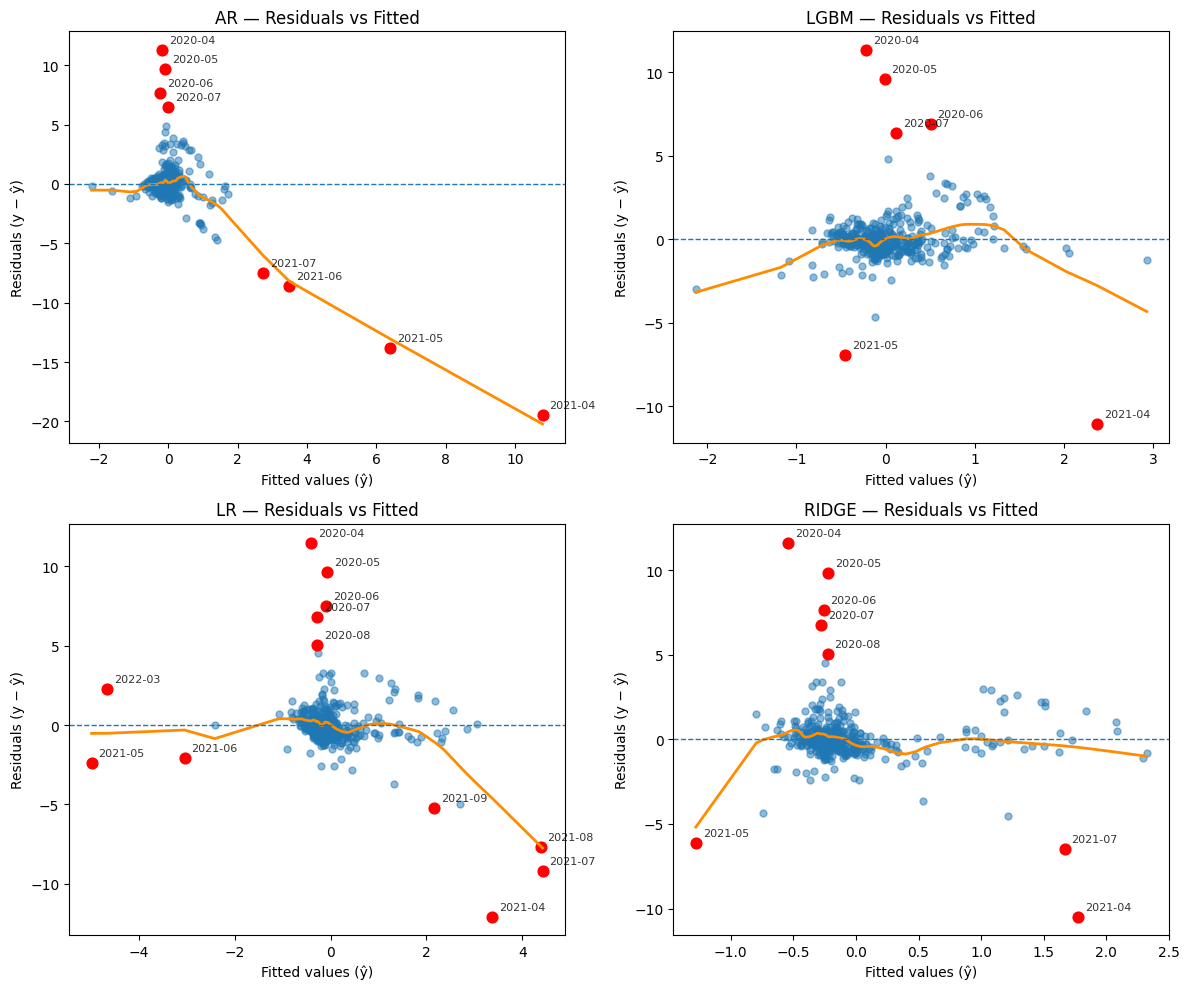

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

# =========================================================
# 1) Préparation
# =========================================================
df = combined_bkt.copy()

df["ds"] = pd.to_datetime(df["ds"], errors="coerce")
df = df.dropna(subset=["ds", "y_true", "y_hat"])
df = df[df["ds"] >= "1990-01-01"]

df["residual"] = df["y_true"] - df["y_hat"]

models = sorted(df["model_label"].unique())

threshold = 5

# =========================================================
# 2) Residuals vs Fitted + nouvelles conditions extrêmes
# =========================================================
n_models = len(models)
n_cols = 2
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, m in zip(axes, models):

    sub = df[df["model_label"] == m].dropna(subset=["y_hat", "residual"])

    x = sub["y_hat"].astype(float)
    y = sub["residual"].astype(float)

    # scatter normal
    ax.scatter(x, y, alpha=0.5, s=25)

    # LOWESS en ORANGE
    smoothed = lowess(endog=y, exog=x, frac=0.30, it=0, return_sorted=True)
    ax.plot(smoothed[:, 0], smoothed[:, 1], color="#FF8C00", linewidth=2)

    # ligne zéro
    ax.axhline(0, linestyle="--", linewidth=1)

    # --------------------------
    # Nouvelle définition extrême
    # --------------------------
    extreme = sub[
        (np.abs(sub["residual"]) > threshold) |
        (sub["y_hat"] < -3)
    ]

    ax.scatter(extreme["y_hat"], extreme["residual"],
               color="red", s=60)

    # afficher date
    for _, row in extreme.iterrows():
        ax.annotate(
            row["ds"].strftime("%Y-%m"),
            (row["y_hat"], row["residual"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8,
            alpha=0.8
        )

    ax.set_title(f"{m} — Residuals vs Fitted")
    ax.set_xlabel("Fitted values (ŷ)")
    ax.set_ylabel("Residuals (y − ŷ)")

# supprimer axes vides
for i in range(len(models), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

The largest forecast errors occur in **2020 and 2021**, during the Covid shock.
In 2022, there is only one additional major error, mainly from the Linear Regression model.

Overall, the models capture unemployment dynamics well.
They struggle mostly during sudden and extreme shocks.
Outside these episodes, forecasts remain aligned with macroeconomic trends.

A divergence appears after the initial shock.
The AR model reacts with a delay.
It shows similarly large errors in both 2020 and 2021.
When it predicts rising unemployment, the rate has often already begun to fall.

In contrast, the multivariate models (LR, Ridge, LGBM) adjust more smoothly.
LightGBM adapts faster after the crisis.
It reduces errors more quickly than the other models.

In [91]:
import numpy as np
import pandas as pd

df = combined_bkt.copy()

df["ds"] = pd.to_datetime(df["ds"], errors="coerce")
df = df.dropna(subset=["ds", "y_true", "y_hat"])

# résidu signé
df["residual"] = df["y_true"] - df["y_hat"]

threshold = 5
fit_threshold = -3  # NEW

# =========================================================
# Classification des cas extrêmes (+ fit < -3)
# =========================================================
def classify_extreme(row):
    fit = float(row["y_hat"])
    resid = float(row["residual"])

    # ✅ Nouveau cas : fit très négatif
    if fit < fit_threshold:
        return "Partie 0: fit<-3"

    # Cas extrêmes résiduels (comme avant)
    if fit < 0 and resid > threshold:
        return "Partie 1: fit<0 & resid>5"

    elif fit < 0 and resid < -threshold:
        return "Partie 2: fit<0 & resid<-5"

    elif fit > 0 and resid < -threshold:
        return "Partie 3: fit>0 & resid<-5"

    elif fit > 0 and resid > threshold:
        return "Partie 4: fit>0 & resid>5"

    else:
        return np.nan  # on ne garde pas les autres


df["zone"] = df.apply(classify_extreme, axis=1)

# =========================================================
# df_long final (uniquement cas extrêmes)
# =========================================================
df_long = (
    df.dropna(subset=["zone"])
      [["unique_id", "ds", "partition", "model_label",
        "y_true", "y_hat", "residual", "zone"]]
      .sort_values(["ds", "model_label"])
      .reset_index(drop=True)
)

df_long.shape

(34, 8)

In [92]:
df_long

,unique_id,ds,partition,model_label,y_true,y_hat,residual,zone
0,UNRATE,2020-04-01,2020-end,AR,11.1,-0.179114,11.279114,Partie 1: fit<0 & resid>5
1,UNRATE,2020-04-01,2020-end,LGBM,11.1,-0.217669,11.317669,Partie 1: fit<0 & resid>5
2,UNRATE,2020-04-01,2020-end,LR,11.1,-0.405607,11.505607,Partie 1: fit<0 & resid>5
3,UNRATE,2020-04-01,2020-end,RIDGE,11.1,-0.539057,11.639057,Partie 1: fit<0 & resid>5
4,UNRATE,2020-05-01,2020-end,AR,9.6,-0.077575,9.677575,Partie 1: fit<0 & resid>5
5,UNRATE,2020-05-01,2020-end,LGBM,9.6,-0.012018,9.612018,Partie 1: fit<0 & resid>5
6,UNRATE,2020-05-01,2020-end,LR,9.6,-0.078215,9.678215,Partie 1: fit<0 & resid>5
7,UNRATE,2020-05-01,2020-end,RIDGE,9.6,-0.221606,9.821606,Partie 1: fit<0 & resid>5
8,UNRATE,2020-06-01,2020-end,AR,7.4,-0.230170,7.630170,Partie 1: fit<0 & resid>5
9,UNRATE,2020-06-01,2020-end,LGBM,7.4,0.503510,6.896490,Partie 4: fit>0 & resid>5


Au total, le 04 modèle totalie 31 grandes erreurs, analysons

#### Analyse des résidus

# Analye de erreur max par date

## Où le modèle ont fait de erreur? 

In [93]:
df_year = df_long.copy()

df_year["year"] = df_year["ds"].dt.year

errors_per_year_global = (
    df_year
    .groupby("year")
    .size()
    .to_frame("nb_extreme_errors")
    .sort_index()
)

errors_per_year_global

,nb_extreme_errors
year,
2020,18
2021,15
2022,1


The largest errors are concentrated in 2020 and 2021, during the Covid shock.
In 2022, only one major error appears, mainly from the Linear Regression model.

This suggests that, overall, our models capture the dynamics of unemployment reasonably well — even during crisis periods such as the Global Financial Crisis.

In other words, performance deteriorates primarily during extreme and sudden disruptions, but outside these exceptional shocks, the models remain consistent with underlying macroeconomic trends.

## Quel modèle ouffrent plu d'une année à l'autre? 

In [94]:
df_year = df_long.copy()

df_year["year"] = df_year["ds"].dt.year

errors_per_year_model = (
    df_year
    .groupby(["year", "model_label"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

errors_per_year_model

model_label,AR,LGBM,LR,RIDGE
year,,,,
2020,4,4,5,5
2021,4,2,6,3
2022,0,0,1,0


All models exhibit large errors in 2020, and again in 2021.
The Linear Regression model shows an additional large error in 2022.

However, a divergence appears after the initial shock.
AR records similarly large errors in both 2020 and 2021.

In contrast, a clear reduction in large errors is observed for LightGBM after 2020.

## Pourquoi AR a fait autant d'erreur? 

In [95]:
import pandas as pd
import matplotlib.pyplot as plt

df_plot = df_long.copy()
df_plot["ds"] = pd.to_datetime(df_plot["ds"])
df_plot["year"] = df_plot["ds"].dt.year

# erreur absolue (résidu déjà disponible)
df_plot["abs_error"] = df_plot["residual"].abs()

# Nombre d’erreurs à garder
top_n = {
    2020: {"AR": 4, "LGBM": 4, "LR": 5, "RIDGE": 5},
    2021: {"AR": 4, "LGBM": 2, "LR": 4, "RIDGE": 3},
}

rows = []

for year, models in top_n.items():
    for model, n in models.items():
        subset = df_plot[
            (df_plot["year"] == year) &
            (df_plot["model_label"] == model)
        ].copy()

        subset = subset.nlargest(n, "abs_error")
        rows.append(subset)

df_extreme = pd.concat(rows).sort_values("ds")

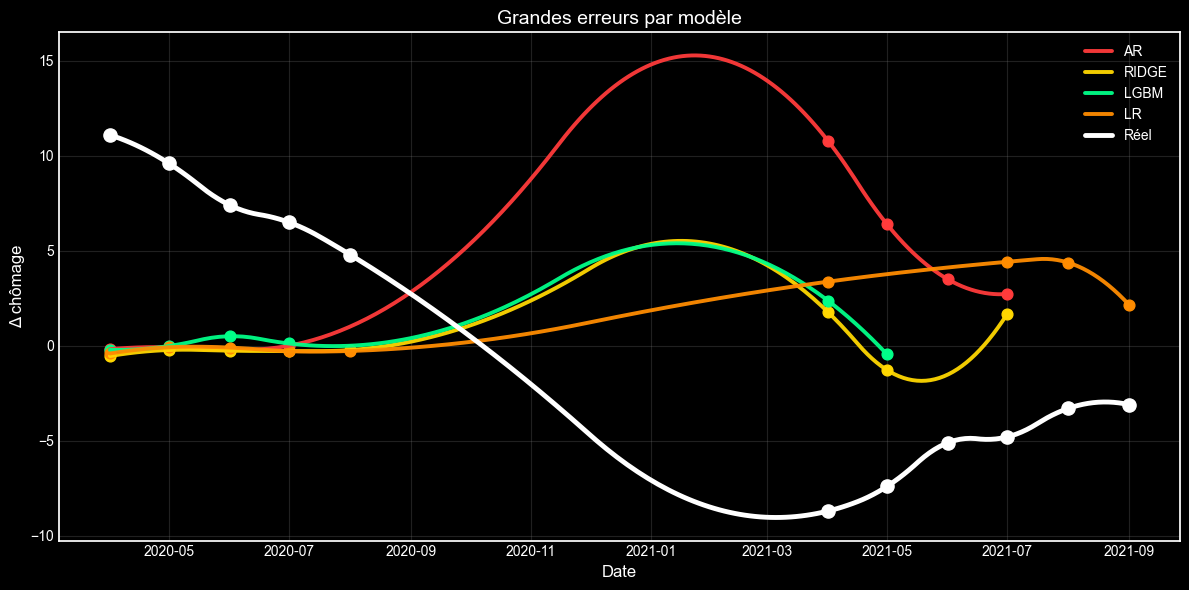

In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

plt.style.use("dark_background")

# 🎨 Palette personnalisée (progression logique)
color_map = {
    "AR": "#ff3b3b",        # rouge
    "LR": "#ff8c00",        # orange
    "RIDGE": "#ffd700",     # jaune
    "LGBM": "#00ff88"       # vert (ancien vert AR)
}

fig = plt.figure(figsize=(12,6))
ax = plt.gca()

for model in df_extreme["model_label"].unique():
    tmp = df_extreme[df_extreme["model_label"] == model].copy()
    tmp["ds"] = pd.to_datetime(tmp["ds"], errors="coerce")
    tmp = tmp.dropna(subset=["ds"]).sort_values("ds")

    base = tmp["ds"].min()
    x = (tmp["ds"] - base).dt.days.astype(float).to_numpy()
    y = tmp["y_hat"].to_numpy()

    color = color_map.get(model, "white")

    if len(x) >= 4:
        x_new = np.linspace(x.min(), x.max(), 200)
        spline = make_interp_spline(x, y, k=2)
        y_smooth = spline(x_new)
        ds_new = base + pd.to_timedelta(x_new, unit="D")

        ax.plot(
            ds_new,
            y_smooth,
            linewidth=2.8,
            alpha=0.95,
            color=color,
            label=model
        )

    ax.scatter(tmp["ds"], tmp["y_hat"], s=60, color=color)

# ----- Ligne réelle -----
real_extreme = df_extreme.drop_duplicates("ds").copy()
real_extreme["ds"] = pd.to_datetime(real_extreme["ds"])
real_extreme = real_extreme.sort_values("ds")

base_r = real_extreme["ds"].min()
x_r = (real_extreme["ds"] - base_r).dt.days.astype(float).to_numpy()
y_r = real_extreme["y_true"].to_numpy()

if len(x_r) >= 4:
    x_new_r = np.linspace(x_r.min(), x_r.max(), 200)
    spline_r = make_interp_spline(x_r, y_r, k=2)
    y_smooth_r = spline_r(x_new_r)
    ds_new_r = base_r + pd.to_timedelta(x_new_r, unit="D")

    ax.plot(ds_new_r, y_smooth_r,
            color="white",
            linewidth=3.5,
            label="Réel")

ax.scatter(real_extreme["ds"],
           real_extreme["y_true"],
           color="white",
           s=90)

# ----- Style -----
ax.set_title("Grandes erreurs par modèle", fontsize=14, color="white")
ax.set_xlabel("Date", fontsize=12, color="white")
ax.set_ylabel("Δ chômage", fontsize=12, color="white")

ax.grid(color="gray", alpha=0.25)
ax.tick_params(colors="white")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

This graph shows the biggest forecast errors in 2020–2021.

The AR model, purely univariate, reacts with a delay. It makes the mistake first and adjusts later. When it predicts rising unemployment, the rate has often already started to fall.

The multivariate models (LR, Ridge, LGBM) follow smoother paths and adjust better to the shock.

LightGBM stands out for its ability to adapt quickly after the crisis, reducing errors faster than the others.